# 可视化测试 - 2022世界杯决赛

本notebook用于测试交互式可视化工具在2022世界杯决赛数据上的运行

**比赛**: 阿根廷 vs 法国 (Game ID: 10517)

**测试内容**:
1. 数据加载
2. 模型加载
3. 图创建和缩放
4. 交互式可视化
5. 接球概率预测
6. 注意力权重分析

## 1. 导入必要的库

In [1]:
# 标准库导入
import os
import pickle
import gc
import sys

# 添加父目录到Python路径（用于导入项目模块）
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"✓ 已添加父目录到Python路径: {parent_dir}")

# 数据处理导入
import pandas as pd
import numpy as np

# PyTorch导入
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader

# 自定义模块导入
import convert_tracking as ct
import plot_functions as pf
import create_graph as cg
import scale_graph as sg
import visualisation
from GNNs.GAT import GATReceptionPredictor
import GNNs.convert_data as cd

print("✓ 所有库导入成功")

✓ 已添加父目录到Python路径: e:\JerryWu\Master\SoccerAnalytics\TrackingData_literature_code\Evaluating Defensive Influence Using GATs-main (modified for 2022 WC)
✓ 所有库导入成功


## 2. 配置参数

In [2]:
# 2022世界杯决赛配置
GAME_ID = '10517'
DATA_DIR = f'Data/{GAME_ID}'
XT_GRID_PATH = 'xT_grid.csv'

# 模型和缩放器路径
MODEL_PATH = f'results/model_final_{GAME_ID}.pth'
SCALER_PATH = f'results/scaler_final_{GAME_ID}.pkl'

# 测试参数
MAX_GRAPHS = 100  # 用于测试的图数量（可以调整）

print(f"配置完成:")
print(f"  比赛ID: {GAME_ID}")
print(f"  数据目录: {DATA_DIR}")
print(f"  最大图数: {MAX_GRAPHS}")

配置完成:
  比赛ID: 10517
  数据目录: Data/10517
  最大图数: 100


## 3. 加载xT网格和元数据

In [3]:
# 加载xT网格
print("加载xT网格...")
if os.path.exists(XT_GRID_PATH):
    xT_grid = pd.read_csv(XT_GRID_PATH, header=None)
    print(f"✓ xT网格加载成功: {xT_grid.shape}")
else:
    print("创建默认xT网格...")
    xT_grid = pd.DataFrame(np.linspace(0, 1, 12*8).reshape(12, 8))
    print(f"✓ 默认xT网格创建完成")

# 加载元数据
print("\n加载元数据...")
(
    home_team_id, away_team_id, home_team_name, away_team_name, 
    home_team_start_left, rosters_for_game_home, rosters_for_game_away,
    roster_game_home_name_dict, roster_game_home_team_name_dict, roster_game_home_pos_dict,
    roster_game_away_name_dict, roster_game_away_team_name_dict, roster_game_away_pos_dict,
    pitch_x_adjustment, pitch_y_adjustment
) = ct.get_metadata(GAME_ID)

print(f"✓ 元数据加载成功")
print(f"  比赛: {home_team_name} vs {away_team_name}")
print(f"  主队开球方向: {'左' if home_team_start_left else '右'}")

加载xT网格...
创建默认xT网格...
✓ 默认xT网格创建完成

加载元数据...
✓ 元数据加载成功
  比赛: Argentina vs France
  主队开球方向: 左


## 4. 加载处理后的数据

In [4]:
# 加载数据框
print("加载处理后的数据...")
balls_df = pd.read_csv(f'{DATA_DIR}/balls_{GAME_ID}.csv')
events_df = pd.read_csv(f'{DATA_DIR}/events_{GAME_ID}.csv')
players_df = pd.read_csv(f'{DATA_DIR}/players_{GAME_ID}.csv')

# 计算球的速度
if 'velocity_x' not in balls_df.columns:
    balls_df = ct.calculate_ball_velocities(balls_df)

print(f"✓ 数据加载成功")
print(f"  球追踪点: {len(balls_df)}")
print(f"  事件数: {len(events_df)}")
print(f"  球员追踪点: {len(players_df)}")

加载处理后的数据...
✓ 数据加载成功
  球追踪点: 253828
  事件数: 1700
  球员追踪点: 5584215


## 5. 创建图数据集（测试用）

为了快速测试，只创建前N个事件帧的图。

In [5]:
# 创建图数据集
print(f"为前{MAX_GRAPHS}个事件帧创建图...")
print("注意: 这可能需要1-2分钟\n")

graphs = []
event_frames = events_df['frameNum'].values[:MAX_GRAPHS]
success_count = 0
fail_count = 0

for i, frameNum in enumerate(event_frames):
    try:
        G = cg.create_normalized_graph_directed(
            players_df, balls_df, events_df, frameNum, home_team_name
        )
        
        if G is not None:
            graphs.append(G)
            success_count += 1
        else:
            fail_count += 1
            
        if (i + 1) % 20 == 0:
            print(f"  进度: {i + 1}/{len(event_frames)} ({100*(i+1)/len(event_frames):.1f}%)")
            
    except Exception as e:
        fail_count += 1
        if fail_count <= 3:
            print(f"  警告: 帧 {frameNum} 失败: {e}")

print(f"\n✓ 图创建完成")
print(f"  成功: {success_count}")
print(f"  失败: {fail_count}")
print(f"  总图数: {len(graphs)}")

为前100个事件帧创建图...
注意: 这可能需要1-2分钟

  进度: 20/100 (20.0%)
  进度: 40/100 (40.0%)
  进度: 60/100 (60.0%)
  进度: 80/100 (80.0%)
  进度: 100/100 (100.0%)

✓ 图创建完成
  成功: 88
  失败: 12
  总图数: 88


## 6. 图特征缩放

In [6]:
# 缩放图特征
print(f"缩放 {len(graphs)} 个图...")

# 尝试加载已保存的缩放器
if os.path.exists(SCALER_PATH):
    print(f"加载已保存的缩放器: {SCALER_PATH}")
    with open(SCALER_PATH, 'rb') as f:
        graph_scaler = pickle.load(f)
    print("✓ 缩放器加载成功")
else:
    print("创建新的缩放器...")
    graph_scaler = sg.GraphFeatureScaler()
    graph_scaler.fit(graphs)
    print("✓ 缩放器已拟合")

# 转换图
scaled_graphs = [graph_scaler.transform_graph(G) for G in graphs]
print(f"✓ 图已缩放: {len(scaled_graphs)}")

# 验证缩放
if len(graphs) > 0:
    original_features = graphs[0].nodes[list(graphs[0].nodes())[0]]['features']
    scaled_features = scaled_graphs[0].nodes[list(scaled_graphs[0].nodes())[0]]['features']
    print(f"\n特征对比（第一个节点）:")
    print(f"  原始特征范围: [{original_features.min():.2f}, {original_features.max():.2f}]")
    print(f"  缩放后特征范围: [{scaled_features.min():.2f}, {scaled_features.max():.2f}]")

缩放 88 个图...
加载已保存的缩放器: results/scaler_final_10517.pkl
✓ 缩放器加载成功
✓ 图已缩放: 88

特征对比（第一个节点）:
  原始特征范围: [-43.34, 61.66]
  缩放后特征范围: [-0.90, 1.00]


## 7. 加载训练好的模型

In [7]:
# 初始化并加载模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 模型配置
MODEL_CONFIG = {
    'num_node_features': 15,
    'num_edge_features': 6,
    'hidden_channels': 32,
    'edge_hidden_channels': 16,
    'num_heads': 16
}

# 创建模型
loaded_model = GATReceptionPredictor(**MODEL_CONFIG).to(device)

# 加载权重
if os.path.exists(MODEL_PATH):
    model_state = torch.load(MODEL_PATH, map_location=device)
    loaded_model.load_state_dict(model_state)
    print(f"✓ 模型加载成功: {MODEL_PATH}")
else:
    print(f"警告: 模型文件不存在: {MODEL_PATH}")
    print("将使用未训练的模型（结果可能不准确）")

# 模型信息
total_params = sum(p.numel() for p in loaded_model.parameters())
print(f"\n模型参数数: {total_params:,}")

使用设备: cpu
✓ 模型加载成功: results/model_final_10517.pth

模型参数数: 8,113


## 8. 测试接球概率预测

在启动交互式可视化之前，先测试模型预测功能。

In [8]:
# 选择一个测试图
test_graph_idx = min(40, len(scaled_graphs) - 1)

print(f"测试图 {test_graph_idx} 的预测...")
results_df, attention_analysis = visualisation.predict_reception_probabilities(
    loaded_model,
    scaled_graphs[test_graph_idx],
    head_indexes=range(2)
)

print(f"\n✓ 预测完成\n")
print("="*70)
print("接球概率预测（前5名）:")
print("="*70)
print(results_df.head().to_string(index=False))

# 显示注意力权重
if len(results_df) > 0:
    top_player = results_df['player_name'].iloc[0]
    print(f"\n{'='*70}")
    print(f"{top_player} 的注意力权重（前5）:")
    print(f"{'='*70}")
    if top_player in attention_analysis:
        for i, attn in enumerate(attention_analysis[top_player][:5]):
            print(f"  {i+1}. {attn['source_player']:<20} {attn['attention_weight']:.6f}")

测试图 40 的预测...

✓ 预测完成

接球概率预测（前5名）:
       player_name  is_attacking  reception_probability_AT
Nicolas Tagliafico          True                  0.059895
   Rodrigo de Paul          True                  0.059260
      Lionel Messi          True                  0.058093
     Nahuel Molina          True                  0.057348
    Enzo Fernandez          True                  0.053291

Nicolas Tagliafico 的注意力权重（前5）:
  1. Hugo Lloris          0.053875
  2. Dayot Upamecano      0.050439
  3. Raphael Varane       0.050317
  4. Jules Kounde         0.050068
  5. Aurélien Tchouaméni  0.049732


## 9. 可视化示例图

在球场上可视化一个示例图。

可视化图 40...


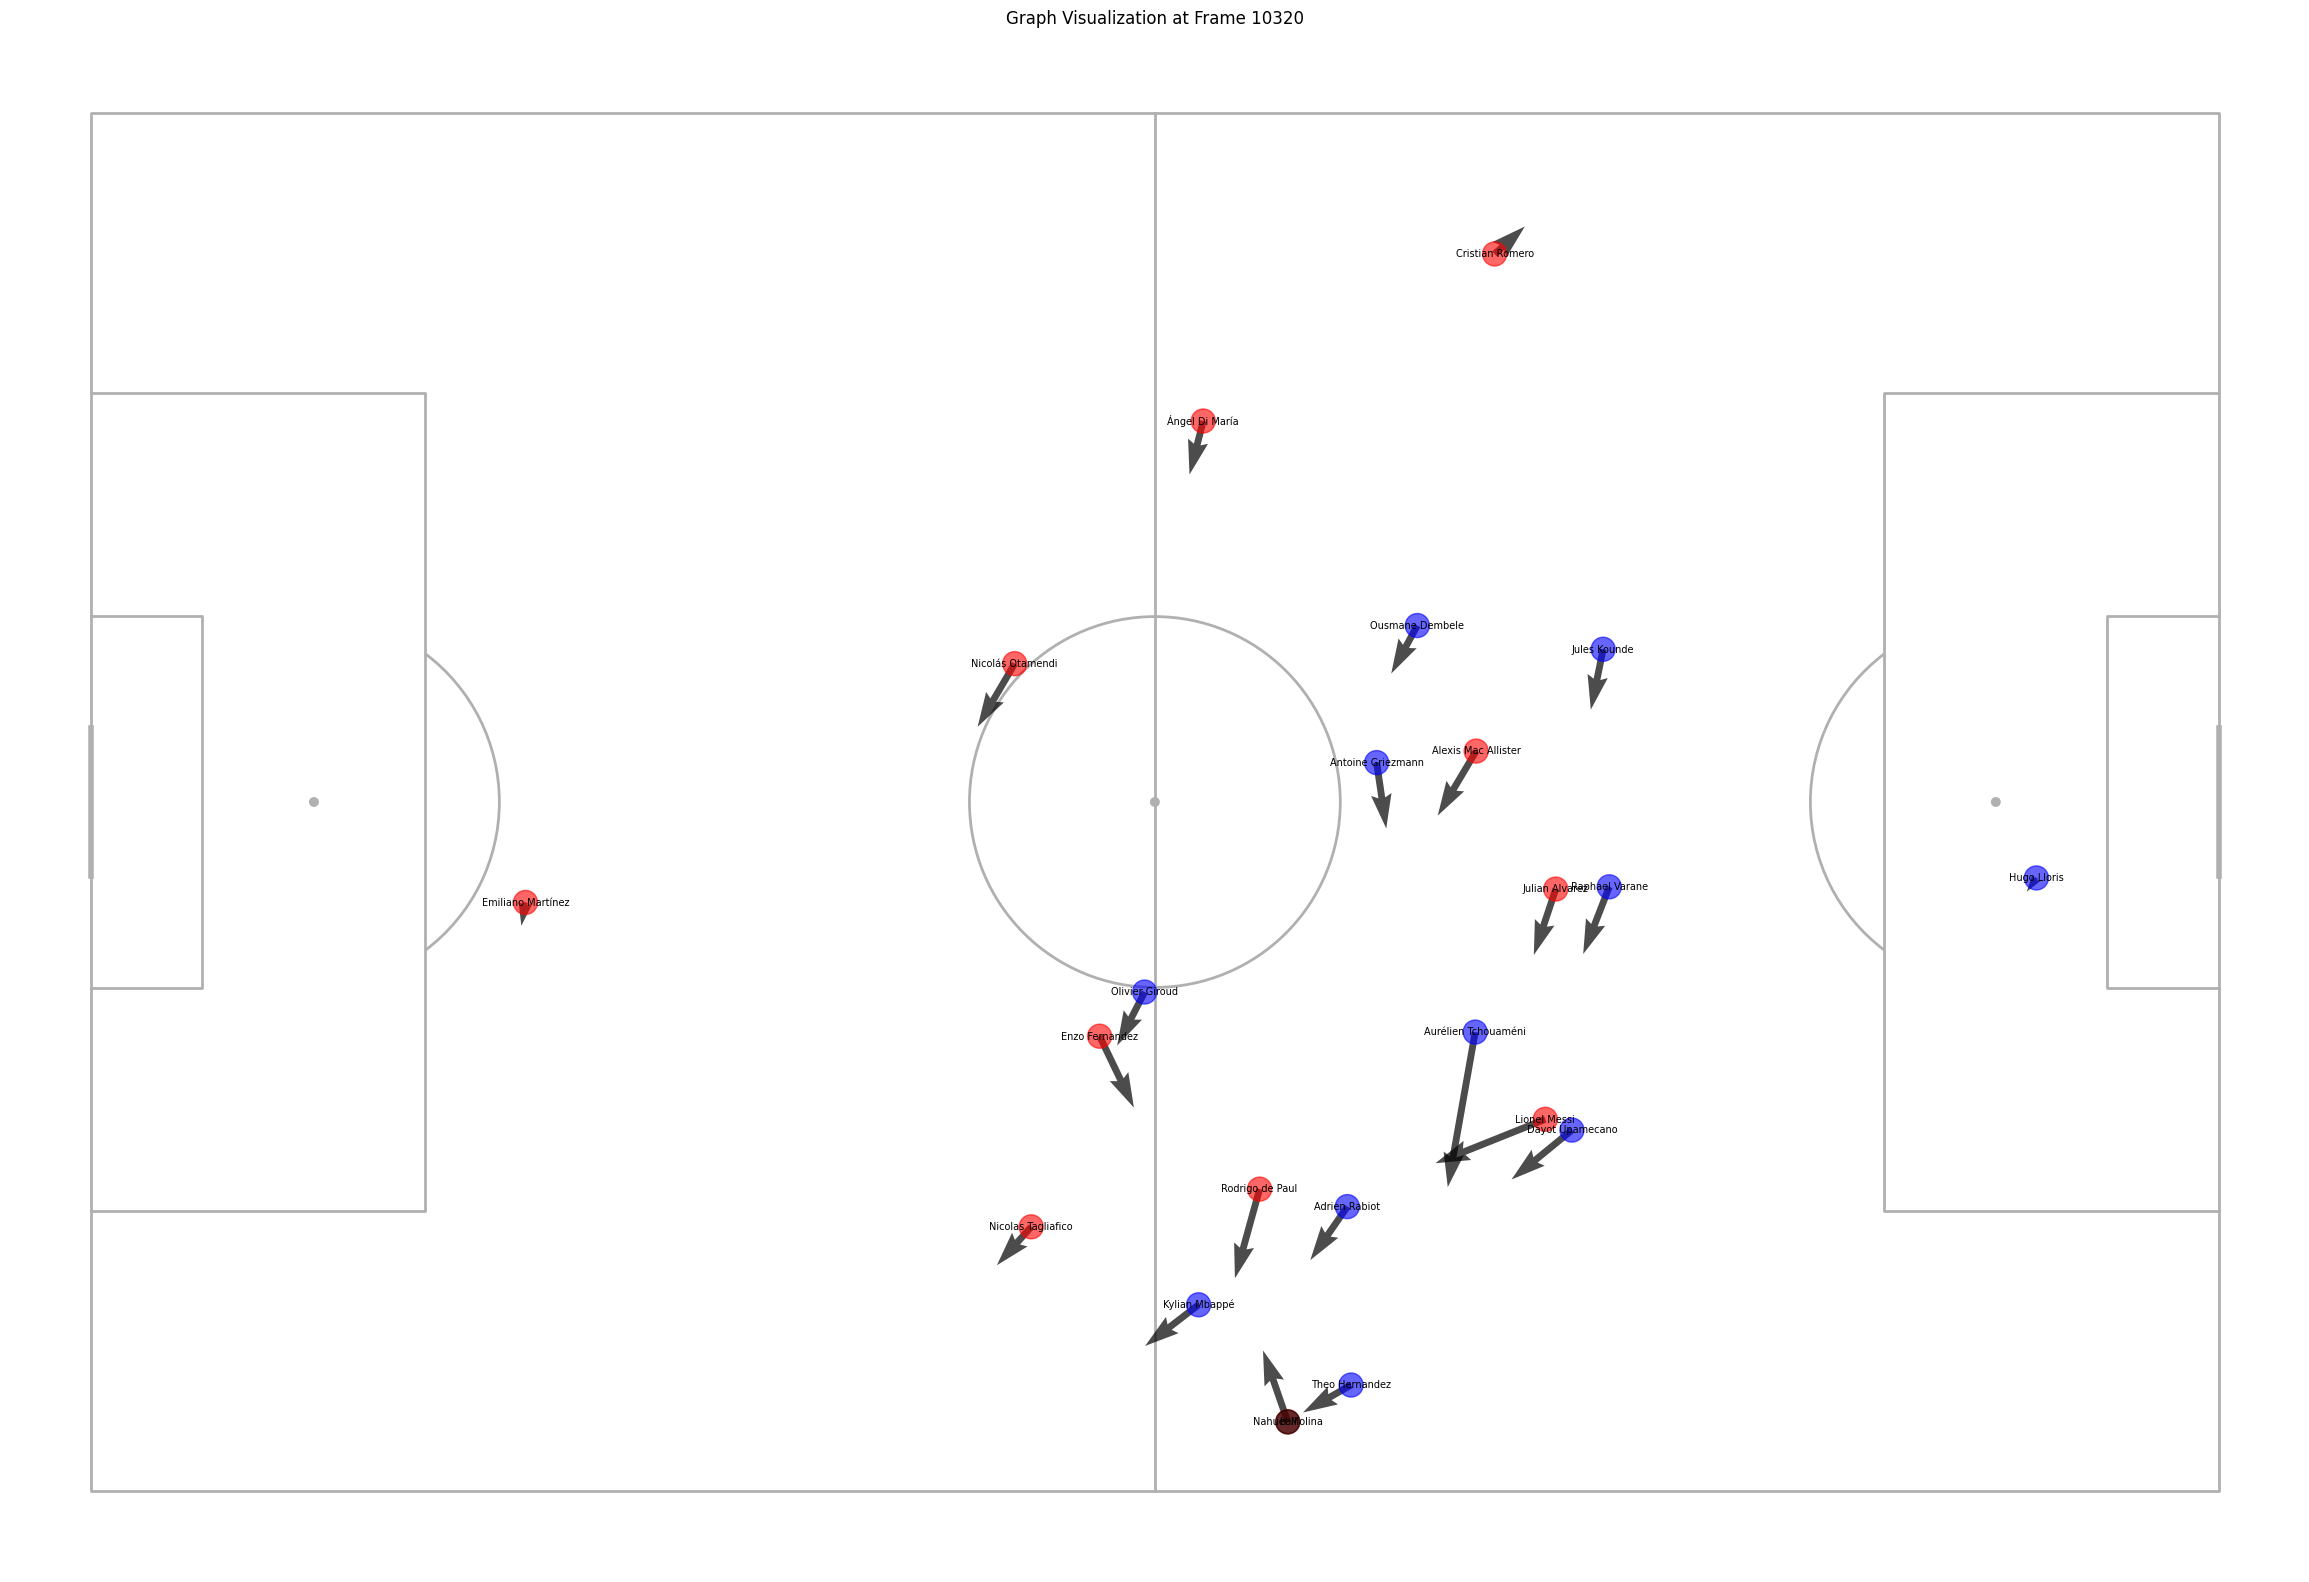


图统计:
  节点数: 23
  边数: 506
  帧编号: 10320


In [9]:
# 可视化测试图
if len(graphs) > test_graph_idx:
    print(f"可视化图 {test_graph_idx}...")
    
    G = graphs[test_graph_idx]
    frame_num = event_frames[test_graph_idx] if test_graph_idx < len(event_frames) else 0
    
    fig, ax = pf.visualize_graph_on_pitch_AT(
        G, 
        sample_timestamp=frame_num,
        ball=True,
        edges=False  # 不显示边，保持清晰
    )
    
    print(f"\n图统计:")
    print(f"  节点数: {G.number_of_nodes()}")
    print(f"  边数: {G.number_of_edges()}")
    print(f"  帧编号: {frame_num}")

## 10. 启动交互式可视化

这是本notebook的核心功能 - 交互式可视化工具。

### 使用提示：

1. **Graph Index**: 使用滑块浏览不同的帧
2. **Defender**: 选择要分析的防守球员
3. **Show Defender Influence**: 显示防守影响力（DI值）
4. **Show Defender Performances**: 显示所有防守球员的表现
5. **Player**: 选择要查看边连接的球员
6. **Show Player Edges**: 显示球员到对方的连接
7. **Show Attention Weights**: 显示注意力权重（线条粗细）

### 颜色说明：
- 🔴 红色 = 进攻球员
- 🔵 蓝色 = 防守球员
- 🟢 绿色 = 选中的防守球员
- ⚫ 黑色 = 球

### 交互功能：
- 可以拖动球员位置查看影响变化
- 实时更新预测结果

In [10]:
# 启动交互式可视化
print("="*70)
print("启动交互式可视化工具")
print("="*70)
print(f"\n比赛: {home_team_name} vs {away_team_name}")
print(f"可用图数: {len(graphs)}")
print(f"\n提示: 可视化将在下方显示")
print("      使用控件探索不同的比赛状态和分析选项")
print("      可以拖动球员位置查看影响变化\n")

visualisation.create_simple_visualization(loaded_model, graphs, scaled_graphs, xT_grid)

启动交互式可视化工具

比赛: Argentina vs France
可用图数: 88

提示: 可视化将在下方显示
      使用控件探索不同的比赛状态和分析选项
      可以拖动球员位置查看影响变化



Output()

## 总结

本notebook成功完成了以下测试：

✓ 数据加载（2022世界杯决赛）  
✓ 图创建和缩放  
✓ 模型加载  
✓ 接球概率预测  
✓ 注意力权重分析  
✓ 交互式可视化工具  

### 探索建议：

1. **分析关键时刻**: 浏览不同的帧，找到比赛的关键时刻
2. **比较防守球员**: 使用"Show Defender Performances"比较不同防守球员的贡献
3. **理解注意力机制**: 使用"Show Attention Weights"查看模型关注的球员交互
4. **测试位置影响**: 拖动球员位置，观察对预测的影响

### 下一步：

- 使用 `Visualisation_2022WC.ipynb` 分析其他比赛
- 使用 `player_eval.py` 进行球员评估
- 使用 `Experiments.ipynb` 进行深入实验

### 相关文件：

- `test_run_gat_model_final.ipynb` - 模型训练测试
- `Visualisation_2022WC.ipynb` - 通用可视化工具
- `RunGATModel_2022WC.ipynb` - 通用模型训练